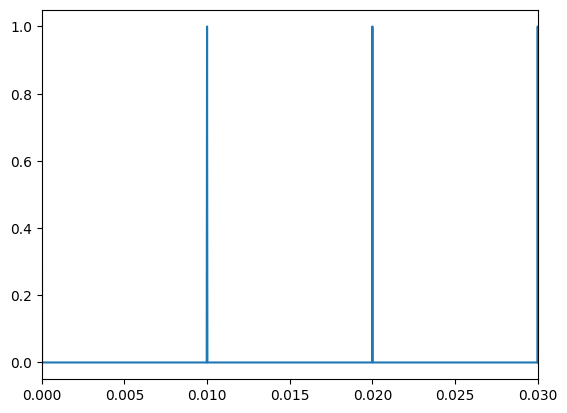

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio

dur = 1.0
fs = 48000
t = np.arange(0, dur, 1/fs)

f0 = 100
T = 1/f0

# Creat train of pulses with period T
x = np.zeros(len(t))
x[np.arange(0, len(t), int(T*fs))] = 1

plt.plot(t,x)
plt.xlim(0, T*3)
plt.show()
Audio(x, rate=fs)

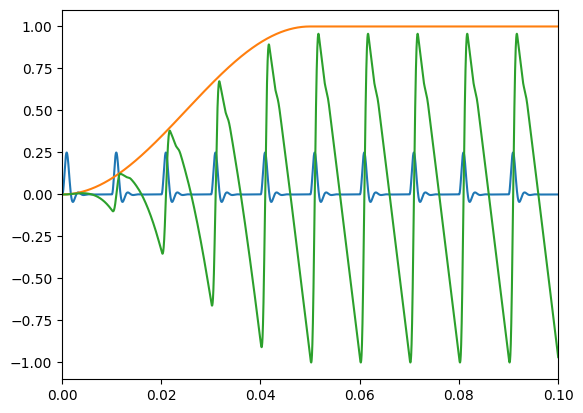

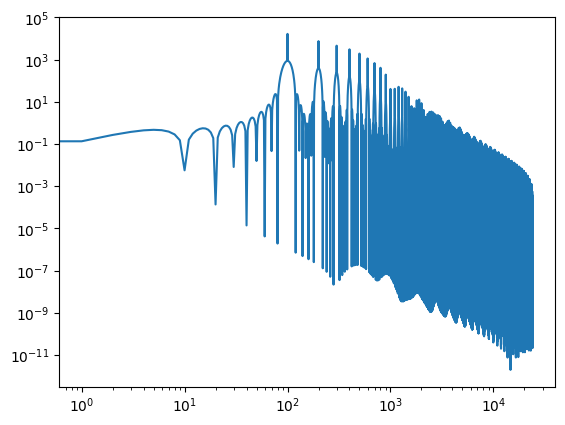

In [14]:
from scipy import signal

# Filter with butterworth fc=2000
b,a = signal.butter(4, 500, 'low', fs=fs)
y = signal.lfilter(b,a,x)

plt.plot(t,y*10)


y[y<0] = 0

y = y - np.mean(y)

y = np.cumsum(y)
y = y-np.mean(y)
y = y/np.max(np.abs(y))

# fadein env
tau = 0.05
env = np.ones(len(y))
env[:int(tau*fs)] = (-np.cos(np.linspace(0, np.pi, int(tau*fs)))+1)/2
env[-int(tau*fs):] = (-np.cos(np.linspace(np.pi, 0, int(tau*fs)))+1)/2
y = y*env 

plt.plot(t,env)

plt.plot(t,y)
plt.xlim(0, T*10)
plt.show()

# plot spectrum
plt.figure()
psd = np.abs(np.fft.rfft(y))
f = np.linspace(0, fs/2, len(psd))
plt.loglog(f, psd)
# plt.xlim(0, 5000)
plt.show()

Audio(y, rate=fs)

In [15]:
# Formant selector

formant_selector = {
    "i": [240, 2400, 2160],
    "y": [235, 2100, 1865],
    "e": [390, 2300, 1910],
    "ø": [370, 1900, 1530],
    "ɛ": [610, 1900, 1290],
    "æ": [585, 1710, 1125],
    "a": [850, 1610, 760],
    "ɶ": [820, 1530, 710],
    "ɑ": [750, 940, 190],
    "ɒ": [700, 760, 60],
    "ʌ": [600, 1170, 570],
    "ɔ": [500, 700, 200],
    "ɤ": [460, 1310, 850],
    "o": [360, 640, 280],
    "ɯ": [300, 1390, 1090],
    "u": [250, 595, 345]
}

850 1610 760


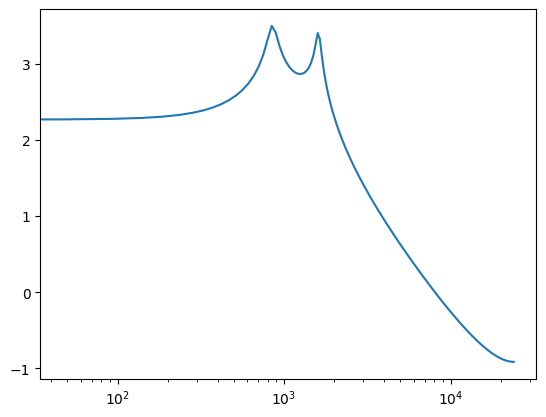

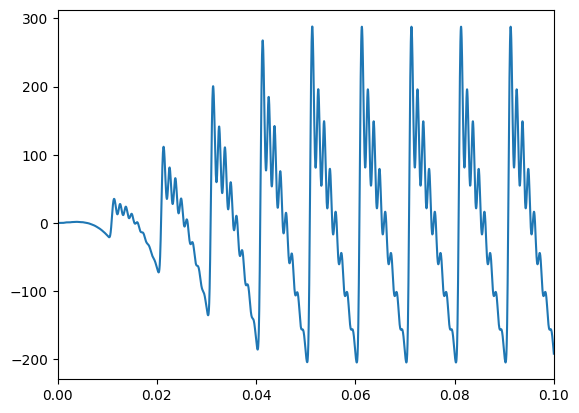

In [16]:
# two pole filter with fc and Q
F1, F2, DF = formant_selector["a"]
print(F1, F2, DF)
BW1 = 100
BW2 = 100
R1=np.exp(-np.pi*BW1/fs)
R2=np.exp(-np.pi*BW2/fs)

# from zeros and poles to coefficients zpk

z = np.array([0.9])
p0 = np.exp(1j*2*np.pi*F1/fs)*R1
p1 = np.exp(1j*2*np.pi*F2/fs)*R2
p = np.array([p0, p1, np.conj(p0), np.conj(p1)])
k = 1

b,a = signal.zpk2tf(z,p,k)

# plot frequency response

f, h =  signal.freqz(b,a,fs=fs)

plt.semilogx(f, np.log10(np.abs(h)))
plt.show()


y = signal.lfilter(b,a,y)
plt.figure()
plt.plot(t,y)
plt.xlim(0, T*10)
plt.show()
Audio(y, rate=fs)

In [17]:
def generate_glottal_source(f0, fs, dur, fc, order):
    t = np.arange(0, dur, 1/fs)
    T = 1/f0

    # Creat train of pulses with period T
    x = np.zeros(len(t))
    x[np.arange(0, len(t), int(T*fs))] = 1

    # Filter with butterworth fc=2000
    b,a = signal.butter(order, fc, 'low', fs=fs)
    y = signal.lfilter(b,a,x)

    y[y<0] = 0

    y = y - np.mean(y)

    y = np.cumsum(y)
    y = y-np.mean(y)
    y = y/np.max(np.abs(y))

    return y

def fadeinout(y, fs, tau):
    env = np.ones(len(y))
    env[:int(tau*fs)] = (-np.cos(np.linspace(0, np.pi, int(tau*fs)))+1)/2
    env[-int(tau*fs):] = (-np.cos(np.linspace(np.pi, 0, int(tau*fs)))+1)/2
    y = y*env 
    return y

def two_pole_filter(y, fs, F1, F2, BW1, BW2):
    R1=np.exp(-np.pi*BW1/fs)    
    R2=np.exp(-np.pi*BW2/fs)

    z = np.array([0.9])
    p0 = np.exp(1j*2*np.pi*F1/fs)*R1
    p1 = np.exp(1j*2*np.pi*F2/fs)*R2
    p = np.array([p0, p1, np.conj(p0), np.conj(p1)])
    k = 1

    b,a = signal.zpk2tf(z,p,k)

    y = signal.lfilter(b,a,y)

    return y


def generate_vowel(f0, fs, dur, tau, fc, order, F1, F2, BW1, BW2):
    y = generate_glottal_source(f0, fs, dur, fc, order)
    y = fadeinout(y, fs, tau)
    y = two_pole_filter(y, fs, F1, F2, BW1, BW2)
    y = y - np.mean(y)
    y = y/np.max(np.abs(y))
    return y

In [18]:
f0 = 100
fs = 48000
dur = 1.0
tau = 0.05
fc = 5000
order = 4
F1, F2, _ = formant_selector["a"]
y = generate_vowel(f0, fs, dur, tau, fc, order, F1, F2, 100, 100)
Audio(y, rate=fs)

i 240 2400
y 235 2100
e 390 2300
ø 370 1900
ɛ 610 1900
æ 585 1710
a 850 1610
ɶ 820 1530
ɑ 750 940
ɒ 700 760
ʌ 600 1170
ɔ 500 700
ɤ 460 1310
o 360 640
ɯ 300 1390
u 250 595


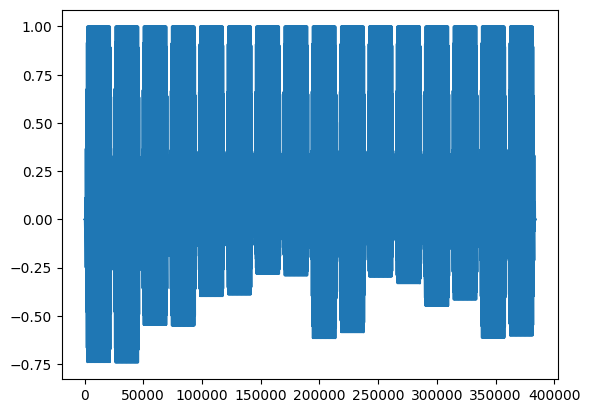

In [19]:
# iterate over vowels
all_vowels = []
dur = 0.5
fc = 3000
order = 2
for vowel in formant_selector:
    F1, F2, _ = formant_selector[vowel]
    print(vowel, F1, F2)
    y = generate_vowel(f0, fs, dur, tau, fc, order, F1, F2, 200, 300)
    y = y - np.mean(y)
    y = y/np.max(np.abs(y))
    all_vowels.append(y)


y = np.concatenate(all_vowels)
plt.plot(y)
plt.show()
Audio(y, rate=fs)

In [20]:
import numpy as np
import matplotlib.pyplot as plt

(0.0, 5000.0)

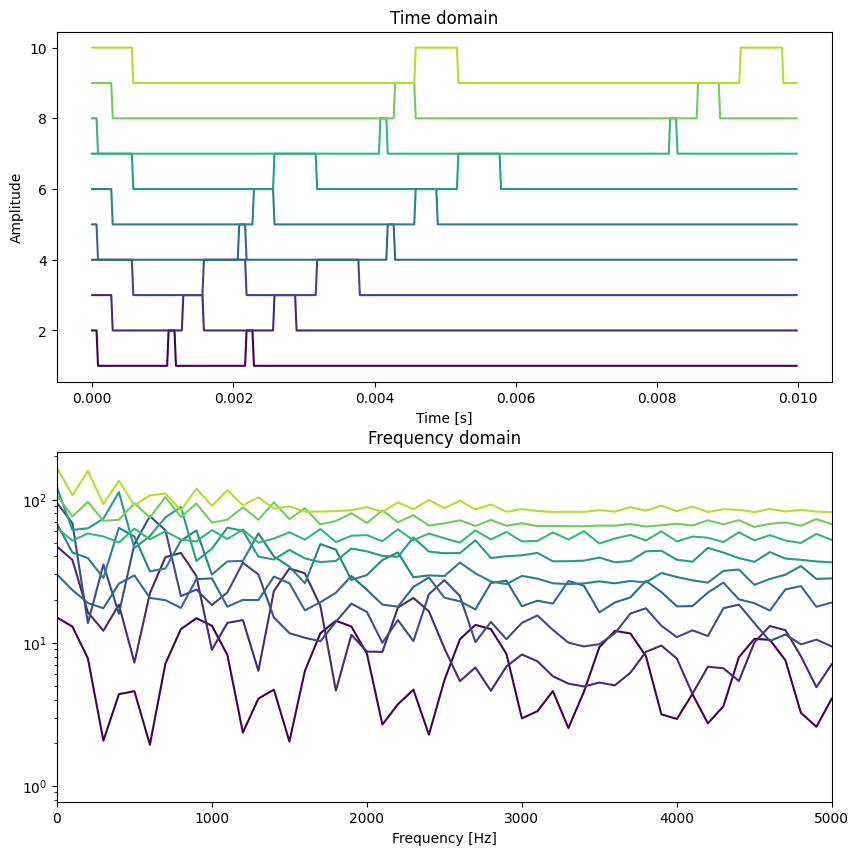

In [21]:
dur = 0.01
sr = 48000
t = np.arange(0, int(dur*sr), 1)/sr



# two plot, one time, one frequency
# explore d and w
fig, ax = plt.subplots(2, 1, figsize=(10, 10))
ax[0].set_title('Time domain')
ax[1].set_title('Frequency domain')
ax[0].set_xlabel('Time [s]')
ax[1].set_xlabel('Frequency [Hz]')
ax[0].set_ylabel('Amplitude')

# colormap cycle
cmap = plt.get_cmap('viridis')
colors = [cmap(i) for i in np.linspace(0, 1, 10)]
ax[0].set_prop_cycle(color=colors)
ax[1].set_prop_cycle(color=colors)

c = 0
for d in [0.001, 0.002, 0.004]:
    for w in [0.0001, 0.0003, 0.0006]:
        # two pulses width w, separation d
        c += 1
        x = np.zeros(len(t))
        x[0:int(sr*(w))] = 1
        x[int(sr*(w+d)):int(sr*(2*w+d))] = 1
        x[int(sr*(2*w+2*d)):int(sr*(3*w+2*d))] = 1
        ax[0].plot(t, x+c, label=f'w={w}, d={d}')
        # plot frequency domain
        ax[1].semilogy(np.fft.rfftfreq(len(x), 1/sr), np.abs(np.fft.rfft(x))+c*c, label=f'w={w}, d={d}')

ax[1].set_xlim(0, 5000)

In [22]:
from IPython.display import Audio
f0 = 100
dur = 4
T = 1/f0
n_cycles = f0*dur

x = np.zeros(int(dur*sr))

w = np.ones(n_cycles)*0.001
d = np.ones(n_cycles)*0.001+np.cos(np.linspace(0, 2*np.pi, n_cycles))*0.0008

for c in range(n_cycles):
    # two pulses width w, separation d
    i0 = int(c*sr*T)
    i1 = int((c+1)*sr*T)
    x[i0:i0+int(sr*(w[c]))] = 1
    x[i0+int(sr*(w[c]+d[c])):i0+int(sr*(2*w[c]+d[c]))] = 0.5
    x[i0+int(sr*(2*w[c]+2*d[c])):i0+int(sr*(3*w[c]+2*d[c]))] = 0.25

# lfilt low pass
from scipy import signal
b, a = signal.butter(12, 2000, 'low', fs=sr)
x = signal.lfilter(b, a, x)
x = signal.lfilter(b, a, x)
Audio(x, rate=sr)